In [ ]:
import numpy as np
import pandas as pd
import math
import os
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import Normalize
from tqdm.auto import tqdm
from astropy.visualization import ZScaleInterval
import argparse
import warnings
warnings.filterwarnings("ignore")

def round_up_to_nearest_10(number):
    return math.ceil(number / 10) * 10

def plot_heatmap(case, bank, all_spectra, xs, info, start_freq=8000, width=100, n_bins=50, var='cos_phi'):
    mask = (xs >= start_freq) & (xs < start_freq + width)
    nans = np.full(xs.shape, np.nan)[mask]
    end_freq = xs[mask][-1]

    info['time_mjd'] = info['time'].apply(lambda mjd: int(mjd.split('_')[0])) #[int(mjd.split('_')[0]) for mjd in info['time']]
    info['cos_theta'] = info['theta'].apply(lambda theta: math.cos(math.radians(theta))) #[math.cos(math.radians(theta)) for theta in info['theta']]
    info['cos_phi'] = info['phi'].apply(lambda phi: math.cos(math.radians(phi))) #[math.cos(math.radians(phi)) for phi in info['phi']]

    bounds = (min(info['time_mjd']), max(info['time_mjd'])) if var == 'time_mjd' else (-1, 1)
    bins = np.linspace(*bounds, n_bins+1)
    info['time_mjd_bin'] = pd.cut(info['time_mjd'], bins, labels=False)
    info['cos_theta_bin'] = pd.cut(info['cos_theta'], bins, labels=False)
    info['cos_phi_bin'] = pd.cut(info['cos_phi'], bins, labels=False)

    def create_map(bin_column):
        for i in range(n_bins):
            bin_mask = (info[bin_column] == i).to_numpy()
            spectra = all_spectra[bin_mask][:, mask]
            if spectra.size:
                avg = np.mean(spectra, axis=0)
                yield avg
            else:
                yield nans
        
    heat_map = list(create_map(f'{var}_bin'))

    fig = plt.figure(figsize=(12, 6), layout="tight")
    gs = fig.add_gridspec(1, 2, wspace=0, width_ratios=[3, 1])
    #plt.subplots_adjust(hspace=0.15)

    ax = fig.add_subplot(gs[0])
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(np.array(heat_map))
    vmax = max(vmax, 2 - vmin)
    ndigits = -int(math.floor(math.log10(vmax - 1))) + 1
    vmax = round(vmax, ndigits)
    vmin = 2 - vmax
    norm = Normalize(vmin=vmin, vmax=vmax)
    extent = [np.min(xs[mask]), np.max(xs[mask]), *bounds]

    #im0 = axs[0].imshow(theta_map, extent=extent, origin='lower', norm=norm, aspect='auto')
    im1 = ax.imshow(heat_map, extent=extent, cmap='viridis', origin='lower', norm=norm, aspect='auto') #cmap='RdBu'
    
    #axs[0].set_ylabel(r'$\mathrm{cos}({\theta})$', fontsize=18)
    if var == 'cos_phi':
        label = r'$\mathrm{cos}({\phi})$'
    elif var == 'cos_theta':
        label = r'$\mathrm{cos}({\theta})$'
    else:
        label = 'Modified JD'

    ax.set_ylabel(label, fontsize=18)
    ax.set_xlabel(r'$\nu$ [MHz]', fontsize=18)
    # for i in bins:
    #     ax.axhline(i, c='r')

    hist_ax = fig.add_subplot(gs[1])
    hist_ax.hist(info[var], bins=bins, facecolor='lightgray', edgecolor='k', orientation='horizontal')
    hist_ax.set_xlabel('Counts', fontsize=18)
    hist_ax.set_yticks([])
    hist_ax.set_ylim(*bounds)

    if var != 'time_mjd':
        ax.axhline(0, c='r') # Inward/outward division
        hist_ax.axhline(0, c='r') # Inward/outward division
        ax.set_yticks(np.linspace(-1, 1, 9))

    fig.suptitle(f'Bank {bank} {case}: {start_freq:.0f}-{end_freq:.0f} MHz', fontsize=20)
    ax.set_aspect('auto')

    #tick_locs = ax[0].get_xticks
    #axs[0].set_xticklabels([])
    #axs[1].set_xticklabels([round(loc * freqs + min(xs)) for loc in tick_locs])
    cax = fig.add_axes([1, 0.117, 0.025, 0.778])
    cbar = fig.colorbar(im1, cax=cax, ax=ax, orientation='vertical', ticks=np.linspace(vmin, vmax, 5))
    cbar.set_label('Normalized Power', fontsize=18)
    
    return fig

/home/bhanselman/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Load in norm gain mean
norm_gain_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/data/normalized_gains/1'
xs_gain = np.load(os.path.join(norm_gain_dir, os.listdir(norm_gain_dir)[0]))[0]
norm_gains = np.array([np.load(os.path.join(norm_gain_dir, file))[1] for file in os.listdir(norm_gain_dir)])
norm_gain_mean = np.mean(norm_gains, axis=0)

In [3]:
plt.rcParams.update({'font.size': 14, 'axes.labelsize': 14})

run_name = '071826_01'
n_bins = 50
width = 100

info_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/all_cband_info.csv'

info = pd.read_csv(info_dir)
bank_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/heatmap/052926_01/decay/1'
bank_1_info = info[info['source'].apply(lambda l: l+'.npy').isin(os.listdir(bank_dir))]

if run_name == 'aya':
    info = bank_1_info[~bank_1_info['phi'].between(70, 115)]
else:
    state = np.load(f'/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/target_selection/071826/01/best_state.npy')
    info = bank_1_info[state == 1]

files = info['source'].apply(lambda l: l+'.npy')
all_spectra = np.array([np.load(os.path.join(bank_dir, file))[1] for file in files]) 
#all_spectra = all_spectra / np.mean(all_spectra, axis=0)
#np.array([np.load(os.path.join(bank_dir, file))[1] / norm_gain_mean for file in files])

xs = np.load(os.path.join(bank_dir, os.listdir(bank_dir)[0]))[0]    
start_freqs = np.arange(round_up_to_nearest_10(xs[0])+20, xs[-1], 100)

for var in ['cos_phi']:
    os.makedirs(f'/home/bhanselman/bhanselman/heatmaps/{run_name}', exist_ok=True)
    pdf = PdfPages(f'/home/bhanselman/bhanselman/heatmaps/{run_name}/{var}.pdf')

    for start_freq in tqdm(start_freqs, desc=var):
        fig = plot_heatmap(
            'decay',
            1,
            all_spectra,
            xs,
            info,
            start_freq=start_freq,
            width=width,
            n_bins=n_bins,
            var=var
        )
        pdf.savefig(fig, bbox_inches='tight', dpi=500)
        plt.close(fig)

    pdf.close()

cos_phi:   0%|          | 0/15 [00:00<?, ?it/s]

# 1e-30 injected signal

In [4]:
def plot_heatmap(case, bank, all_spectra, xs, info, n_bins=50, var='cos_phi', resid=False):
    nans = np.full(xs.shape, np.nan)

    info['time_mjd'] = info['time'].apply(lambda mjd: int(mjd.split('_')[0])) #[int(mjd.split('_')[0]) for mjd in info['time']]
    info['cos_theta'] = info['theta'].apply(lambda theta: math.cos(math.radians(theta))) #[math.cos(math.radians(theta)) for theta in info['theta']]
    info['cos_phi'] = info['phi'].apply(lambda phi: math.cos(math.radians(phi))) #[math.cos(math.radians(phi)) for phi in info['phi']]

    bounds = (min(info['time_mjd']), max(info['time_mjd'])) if var == 'time_mjd' else (-1, 1)
    bins = np.linspace(*bounds, n_bins+1)
    info['time_mjd_bin'] = pd.cut(info['time_mjd'], bins, labels=False)
    info['cos_theta_bin'] = pd.cut(info['cos_theta'], bins, labels=False)
    info['cos_phi_bin'] = pd.cut(info['cos_phi'], bins, labels=False)

    def create_map(bin_column):
        for i in range(n_bins):
            bin_mask = (info[bin_column] == i).to_numpy()
            spectra = all_spectra[bin_mask]
            if spectra.size:
                avg = np.mean(spectra, axis=0)
                yield avg
            else:
                yield nans
        
    heat_map = np.array(list(create_map(f'{var}_bin')))
    if resid:
        heat_map = heat_map / np.nanmean(all_spectra, axis=0)

    fig = plt.figure(figsize=(12, 6), layout="tight")
    gs = fig.add_gridspec(1, 2, wspace=0, width_ratios=[3, 1])
    #plt.subplots_adjust(hspace=0.15)

    ax = fig.add_subplot(gs[0])
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(np.array(heat_map))
    vmax = max(vmax, 2 - vmin)
    ndigits = -int(math.floor(math.log10(vmax - 1))) + 1
    vmax = round(vmax, ndigits)
    vmin = 2 - vmax
    norm = Normalize(vmin=vmin, vmax=vmax)
    extent = [np.min(xs), np.max(xs), *bounds]

    #im0 = axs[0].imshow(theta_map, extent=extent, origin='lower', norm=norm, aspect='auto')
    im1 = ax.imshow(heat_map, extent=extent, cmap='RdBu' if resid else 'viridis', origin='lower', norm=norm, aspect='auto')
    
    #axs[0].set_ylabel(r'$\mathrm{cos}({\theta})$', fontsize=18)
    if var == 'cos_phi':
        label = r'$\mathrm{cos}({\phi})$'
    elif var == 'cos_theta':
        label = r'$\mathrm{cos}({\theta})$'
    else:
        label = 'Modified JD'

    ax.set_ylabel(label, fontsize=18)
    ax.set_xlabel(r'$\nu$ [MHz]', fontsize=18)
    # for i in bins:
    #     ax.axhline(i, c='r')

    hist_ax = fig.add_subplot(gs[1])
    hist_ax.hist(info[var], bins=bins, facecolor='lightgray', edgecolor='k', orientation='horizontal')
    hist_ax.set_xlabel('Counts', fontsize=18)
    hist_ax.set_yticks([])
    hist_ax.set_ylim(*bounds)

    if var != 'time_mjd':
        ax.axhline(0, c='r') # Inward/outward division
        hist_ax.axhline(0, c='r') # Inward/outward division
        ax.set_yticks(np.linspace(-1, 1, 9))

    #fig.suptitle(f'Bank {bank} {case}', fontsize=20)
    ax.set_aspect('auto')

    #tick_locs = ax[0].get_xticks
    #axs[0].set_xticklabels([])
    #axs[1].set_xticklabels([round(loc * freqs + min(xs)) for loc in tick_locs])
    cax = fig.add_axes([1, 0.13, 0.025, 0.83])
    cbar = fig.colorbar(im1, cax=cax, ax=ax, orientation='vertical', ticks=np.linspace(vmin, vmax, 5))
    cbar.set_label('Normalized Power Residual' if resid else 'Normalized Power', fontsize=18)
    
    return fig

## Injected

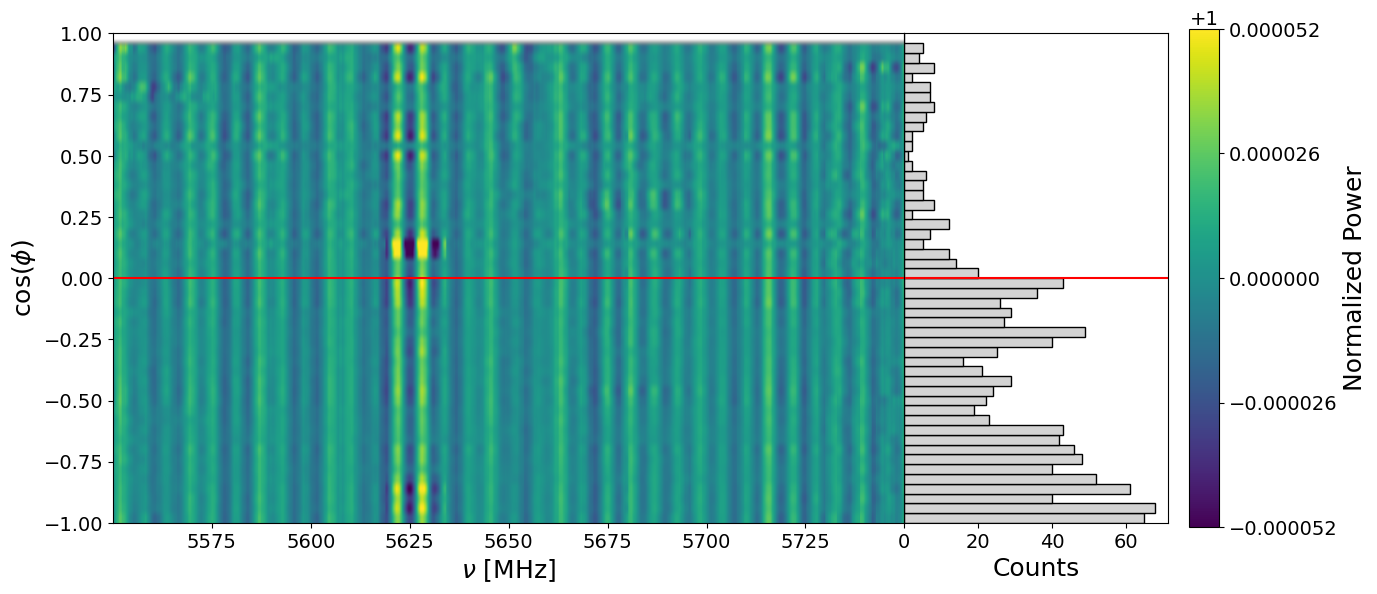

In [5]:
info_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/all_cband_info.csv'
info = pd.read_csv(info_dir)
bank_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/heatmap/052926_01/decay/1'
bank_1_info = info[info['source'].apply(lambda l: l+'.npy').isin(os.listdir(bank_dir))]
state = np.load(f'/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/target_selection/071826/01/best_state.npy')
info = bank_1_info[state == 1]

inj_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/target_selection/norm_1e30_5650_tests/injected'
xs = np.load(os.path.join(inj_dir, files[0]))[0]
inj_spectra = np.array([np.load(os.path.join(inj_dir, file))[1] for file in files])

fig = plot_heatmap(
    'decay',
    1,
    inj_spectra,
    xs,
    info,
    n_bins=50,
    var='cos_phi'
)

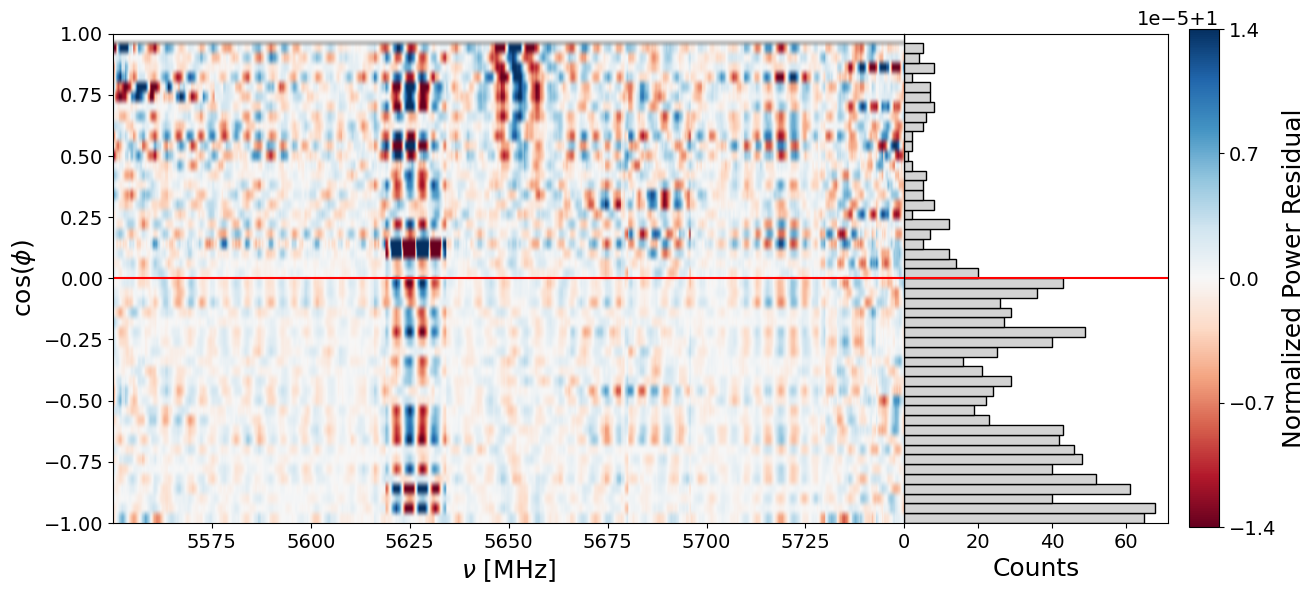

In [6]:
fig = plot_heatmap(
    'decay',
    1,
    inj_spectra,
    xs,
    info,
    n_bins=50,
    var='cos_phi',
    resid=True
)
plt.show()

## Uninjected

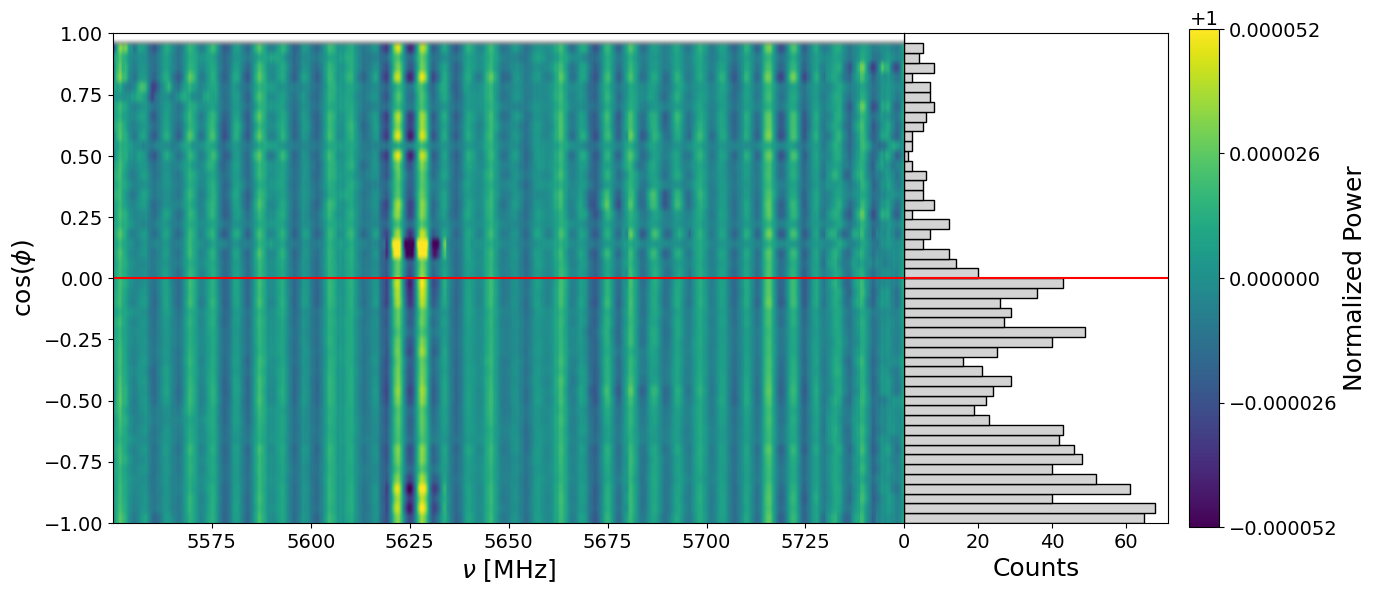

In [7]:
uninj_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/target_selection/norm_1e30_5650_tests/uninjected'
xs = np.load(os.path.join(uninj_dir, files[0]))[0]
uninj_spectra = np.array([np.load(os.path.join(uninj_dir, file))[1] for file in files])

info_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/all_cband_info.csv'
info = pd.read_csv(info_dir)
bank_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/heatmap/052926_01/decay/1'
bank_1_info = info[info['source'].apply(lambda l: l+'.npy').isin(os.listdir(bank_dir))]
state = np.load(f'/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/target_selection/071826/01/best_state.npy')
info = bank_1_info[state == 1]

fig = plot_heatmap(
    'decay',
    1,
    uninj_spectra,
    xs,
    info,
    n_bins=50,
    var='cos_phi'
)

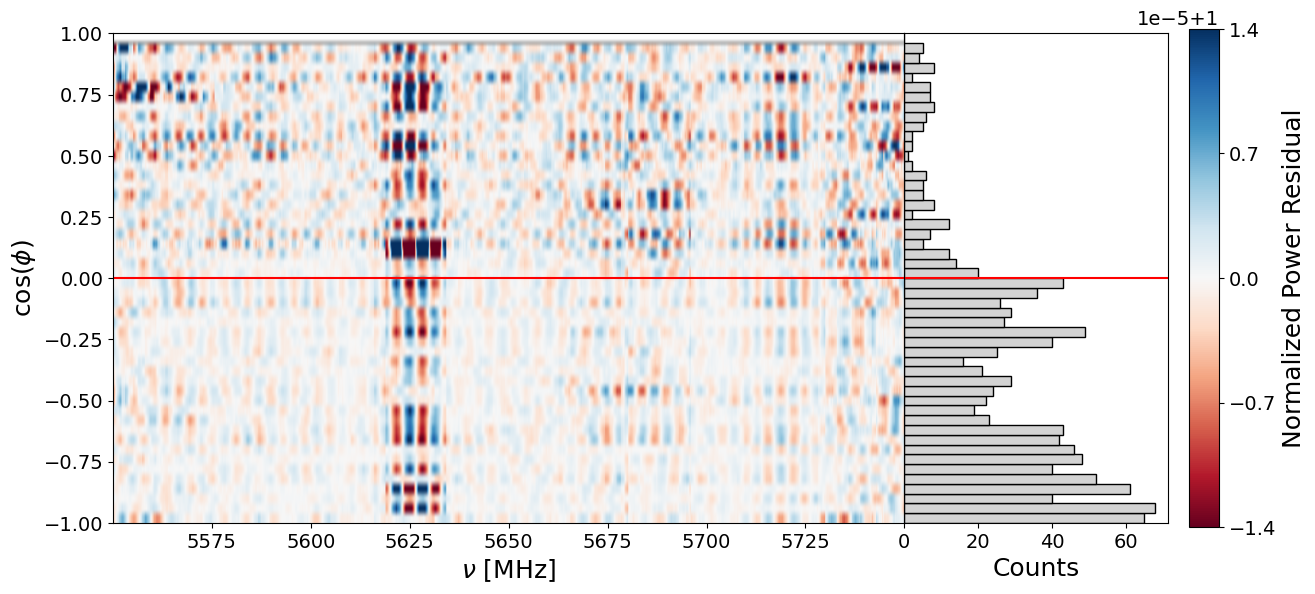

In [8]:
fig = plot_heatmap(
    'decay',
    1,
    uninj_spectra,
    xs,
    info,
    n_bins=50,
    var='cos_phi',
    resid=True
)

## W/ norm gain mean

In [9]:
def plot_heatmap(case, bank, all_spectra, xs, info, n_bins=50, var='cos_phi', resid=None):
    nans = np.full(xs.shape, np.nan)

    info['time_mjd'] = info['time'].apply(lambda mjd: int(mjd.split('_')[0])) #[int(mjd.split('_')[0]) for mjd in info['time']]
    info['cos_theta'] = info['theta'].apply(lambda theta: math.cos(math.radians(theta))) #[math.cos(math.radians(theta)) for theta in info['theta']]
    info['cos_phi'] = info['phi'].apply(lambda phi: math.cos(math.radians(phi))) #[math.cos(math.radians(phi)) for phi in info['phi']]

    bounds = (min(info['time_mjd']), max(info['time_mjd'])) if var == 'time_mjd' else (-1, 1)
    bins = np.linspace(*bounds, n_bins+1)
    info['time_mjd_bin'] = pd.cut(info['time_mjd'], bins, labels=False)
    info['cos_theta_bin'] = pd.cut(info['cos_theta'], bins, labels=False)
    info['cos_phi_bin'] = pd.cut(info['cos_phi'], bins, labels=False)

    def create_map(bin_column):
        for i in range(n_bins):
            bin_mask = (info[bin_column] == i).to_numpy()
            spectra = all_spectra[bin_mask]
            if spectra.size:
                avg = np.mean(spectra, axis=0)
                yield avg
            else:
                yield nans
        
    heat_map = np.array(list(create_map(f'{var}_bin')))
    if resid is not None:
        heat_map = heat_map / resid

    fig = plt.figure(figsize=(12, 6), layout="tight")
    gs = fig.add_gridspec(1, 2, wspace=0, width_ratios=[3, 1])
    #plt.subplots_adjust(hspace=0.15)

    ax = fig.add_subplot(gs[0])
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(np.array(heat_map))
    vmax = max(vmax, 2 - vmin)
    ndigits = -int(math.floor(math.log10(vmax - 1))) + 1
    vmax = round(vmax, ndigits)
    vmin = 2 - vmax
    norm = Normalize(vmin=vmin, vmax=vmax)
    extent = [np.min(xs), np.max(xs), *bounds]

    #im0 = axs[0].imshow(theta_map, extent=extent, origin='lower', norm=norm, aspect='auto')
    im1 = ax.imshow(heat_map, extent=extent, cmap='RdBu' if resid is not None else 'viridis', origin='lower', norm=norm, aspect='auto')
    
    #axs[0].set_ylabel(r'$\mathrm{cos}({\theta})$', fontsize=18)
    if var == 'cos_phi':
        label = r'$\mathrm{cos}({\phi})$'
    elif var == 'cos_theta':
        label = r'$\mathrm{cos}({\theta})$'
    else:
        label = 'Modified JD'

    ax.set_ylabel(label, fontsize=18)
    ax.set_xlabel(r'$\nu$ [MHz]', fontsize=18)
    # for i in bins:
    #     ax.axhline(i, c='r')

    hist_ax = fig.add_subplot(gs[1])
    hist_ax.hist(info[var], bins=bins, facecolor='lightgray', edgecolor='k', orientation='horizontal')
    hist_ax.set_xlabel('Counts', fontsize=18)
    hist_ax.set_yticks([])
    hist_ax.set_ylim(*bounds)

    if var != 'time_mjd':
        ax.axhline(0, c='r') # Inward/outward division
        hist_ax.axhline(0, c='r') # Inward/outward division
        ax.set_yticks(np.linspace(-1, 1, 9))

    #fig.suptitle(f'Bank {bank} {case}', fontsize=20)
    ax.set_aspect('auto')

    #tick_locs = ax[0].get_xticks
    #axs[0].set_xticklabels([])
    #axs[1].set_xticklabels([round(loc * freqs + min(xs)) for loc in tick_locs])
    cax = fig.add_axes([1, 0.13, 0.025, 0.83])
    cbar = fig.colorbar(im1, cax=cax, ax=ax, orientation='vertical', ticks=np.linspace(vmin, vmax, 5))
    cbar.set_label('Normalized Power Residual' if resid is not None else 'Normalized Power', fontsize=18)
    
    return fig

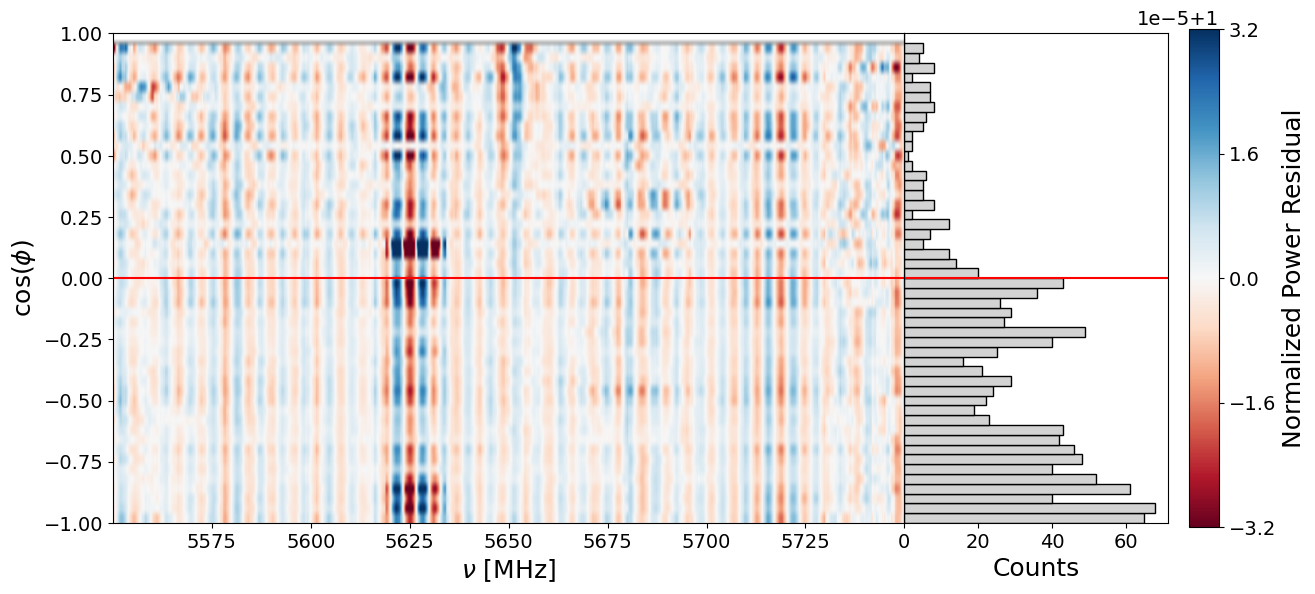

In [10]:
inj_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/target_selection/norm_1e30_5650_tests/injected'
xs = np.load(os.path.join(inj_dir, files[0]))[0]
inj_spectra = np.array([np.load(os.path.join(inj_dir, file))[1] for file in files])

info_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/all_cband_info.csv'
info = pd.read_csv(info_dir)
bank_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/heatmap/052926_01/decay/1'
bank_1_info = info[info['source'].apply(lambda l: l+'.npy').isin(os.listdir(bank_dir))]
state = np.load(f'/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/target_selection/071826/01/best_state.npy')
info = bank_1_info[state == 1]

xs_all = np.load(os.path.join(bank_dir, files[0]))[0]
mask = (xs_all >= xs[0]) & (xs_all <= xs[-1])
norm_gain_mean_masked = norm_gain_mean[mask]

fig = plot_heatmap(
    'decay',
    1,
    inj_spectra,
    xs,
    info,
    n_bins=50,
    var='cos_phi',
    resid=norm_gain_mean_masked
)

Not as good...?

## Doppler (071826/02) - injected

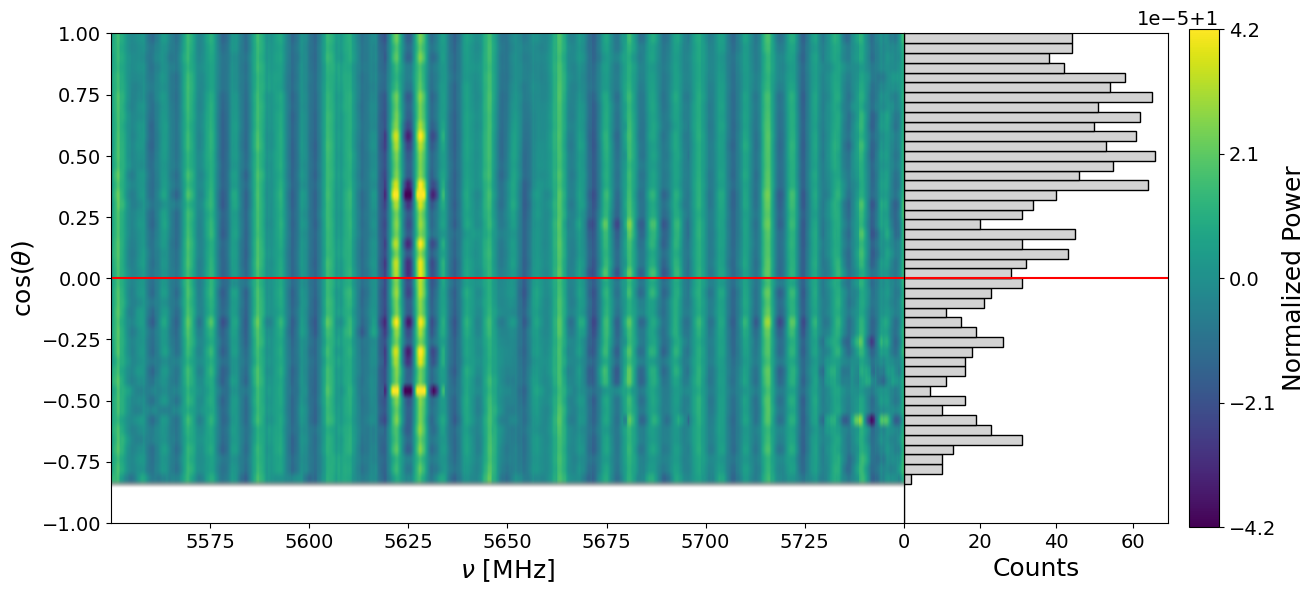

In [11]:
info_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/all_cband_info.csv'
info = pd.read_csv(info_dir)
bank_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/heatmap/052926_01/decay/1'
bank_1_info = info[info['source'].apply(lambda l: l+'.npy').isin(os.listdir(bank_dir))]
state = np.load(f'/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/target_selection/071826/02/best_state.npy')
info = bank_1_info[state == 1]

inj_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/target_selection/norm_1e30_5650_tests/injected'
files = info['source'].apply(lambda l: l+'.npy').to_numpy()
xs = np.load(os.path.join(inj_dir, files[0]))[0]
inj_spectra = np.array([np.load(os.path.join(inj_dir, file))[1] for file in files])

fig = plot_heatmap(
    'decay',
    1,
    inj_spectra,
    xs,
    info,
    n_bins=50,
    var='cos_theta'
)

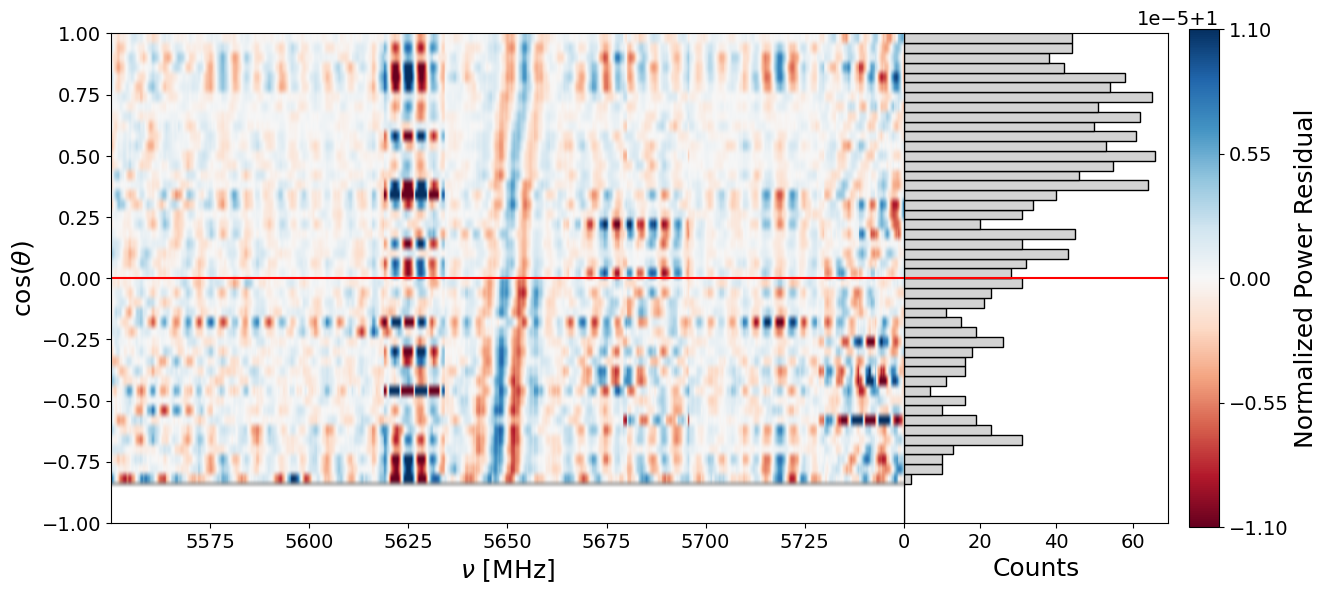

In [12]:
fig = plot_heatmap(
    'decay',
    1,
    inj_spectra,
    xs,
    info,
    n_bins=50,
    var='cos_theta',
    resid=np.nanmean(inj_spectra, axis=0)
)

## Doppler = uninjected

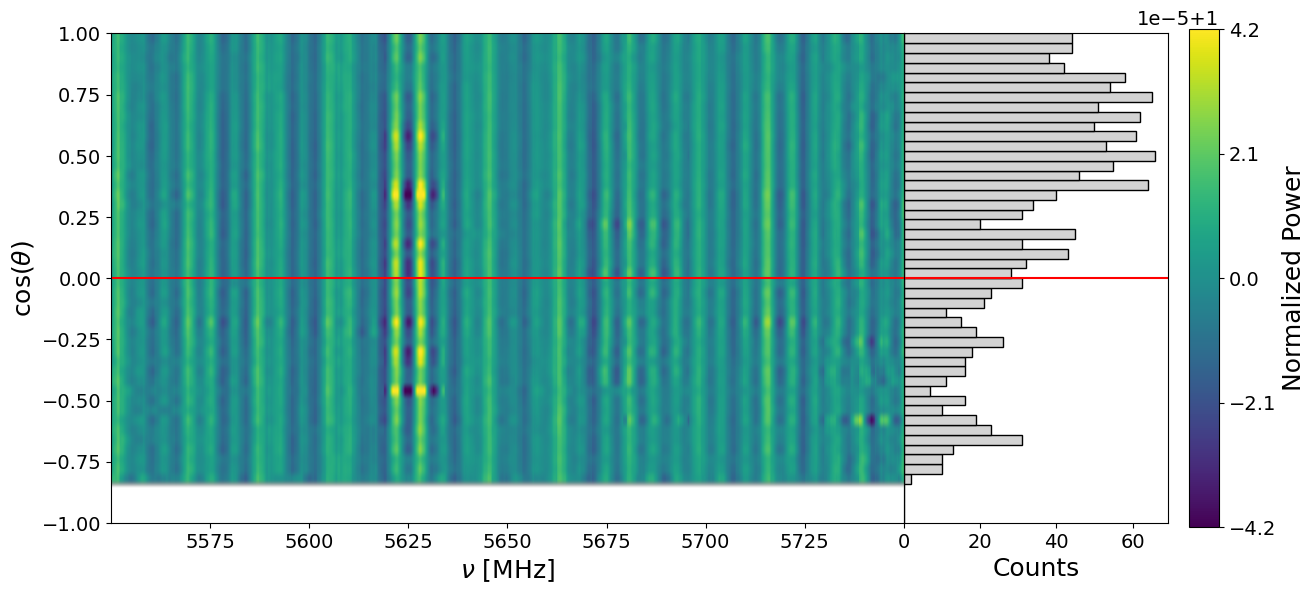

In [13]:
info_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/all_cband_info.csv'
info = pd.read_csv(info_dir)
bank_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/heatmap/052926_01/decay/1'
bank_1_info = info[info['source'].apply(lambda l: l+'.npy').isin(os.listdir(bank_dir))]
state = np.load(f'/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/target_selection/071826/02/best_state.npy')
info = bank_1_info[state == 1]

uninj_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/target_selection/norm_1e30_5650_tests/uninjected'
files = info['source'].apply(lambda l: l+'.npy').to_numpy()
xs = np.load(os.path.join(uninj_dir, files[0]))[0]
uninj_spectra = np.array([np.load(os.path.join(uninj_dir, file))[1] for file in files])

fig = plot_heatmap(
    'decay',
    1,
    uninj_spectra,
    xs,
    info,
    n_bins=50,
    var='cos_theta'
)

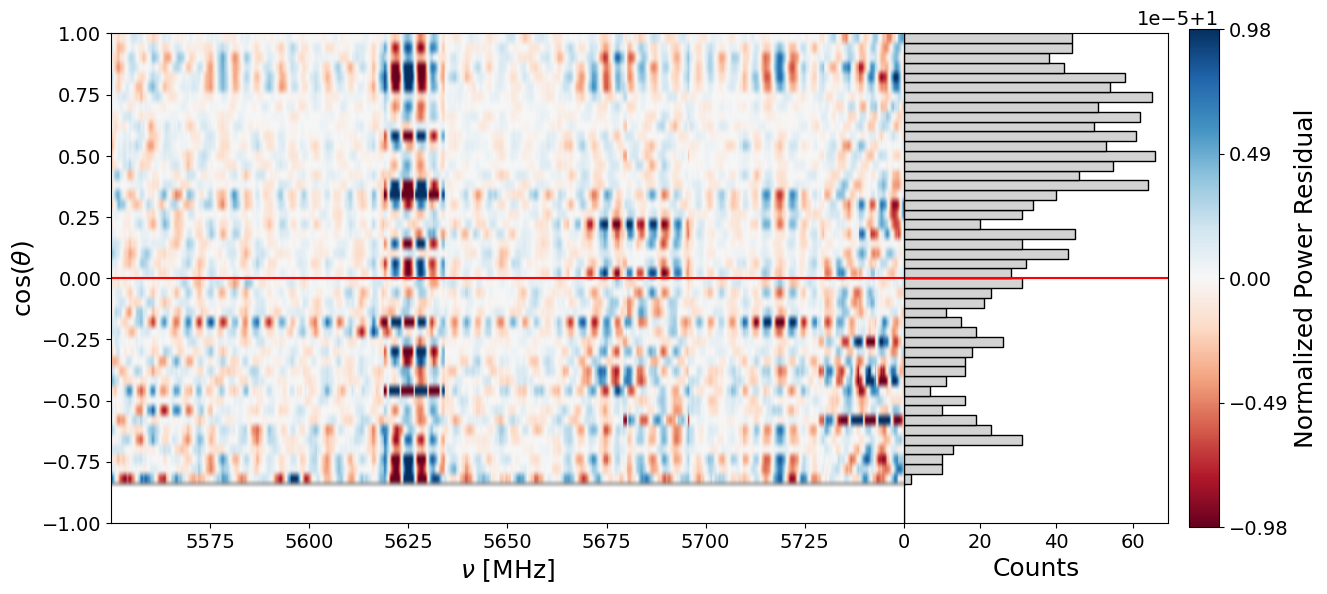

In [14]:
fig = plot_heatmap(
    'decay',
    1,
    uninj_spectra,
    xs,
    info,
    n_bins=50,
    var='cos_theta',
    resid=np.nanmean(uninj_spectra, axis=0)
)

## Doppler- w/ norm gain mean

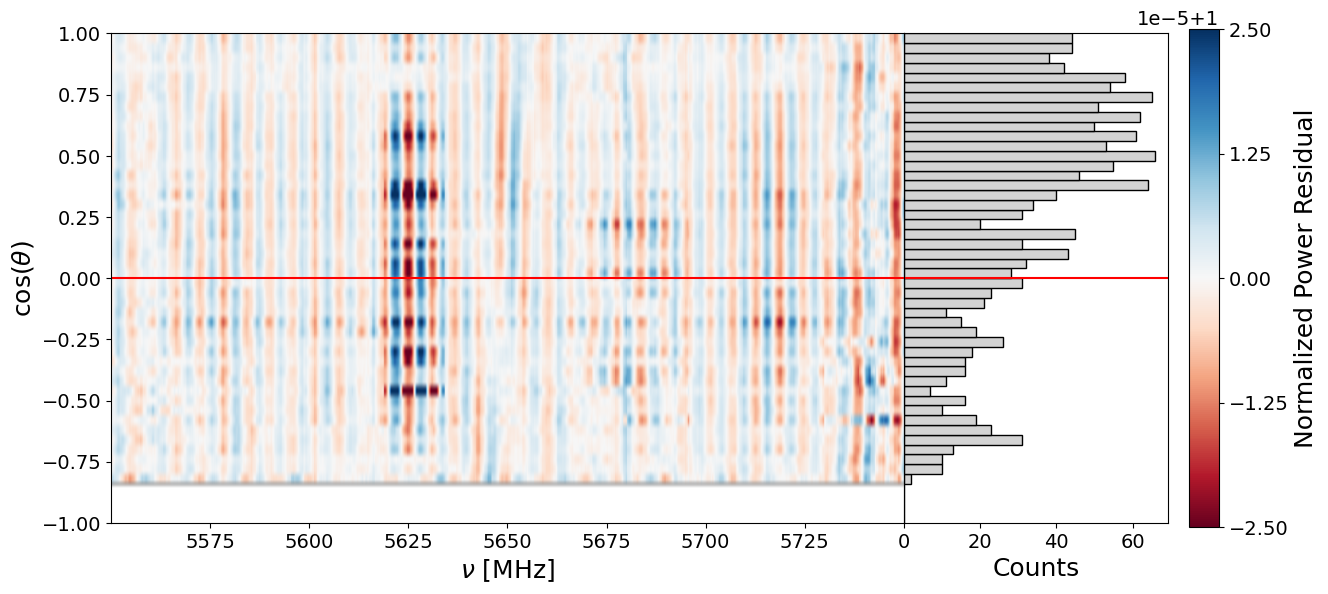

In [15]:
fig = plot_heatmap(
    'decay',
    1,
    inj_spectra,
    xs,
    info,
    n_bins=50,
    var='cos_theta',
    resid=norm_gain_mean_masked
)

### Injected, no division but use RdBu colormap

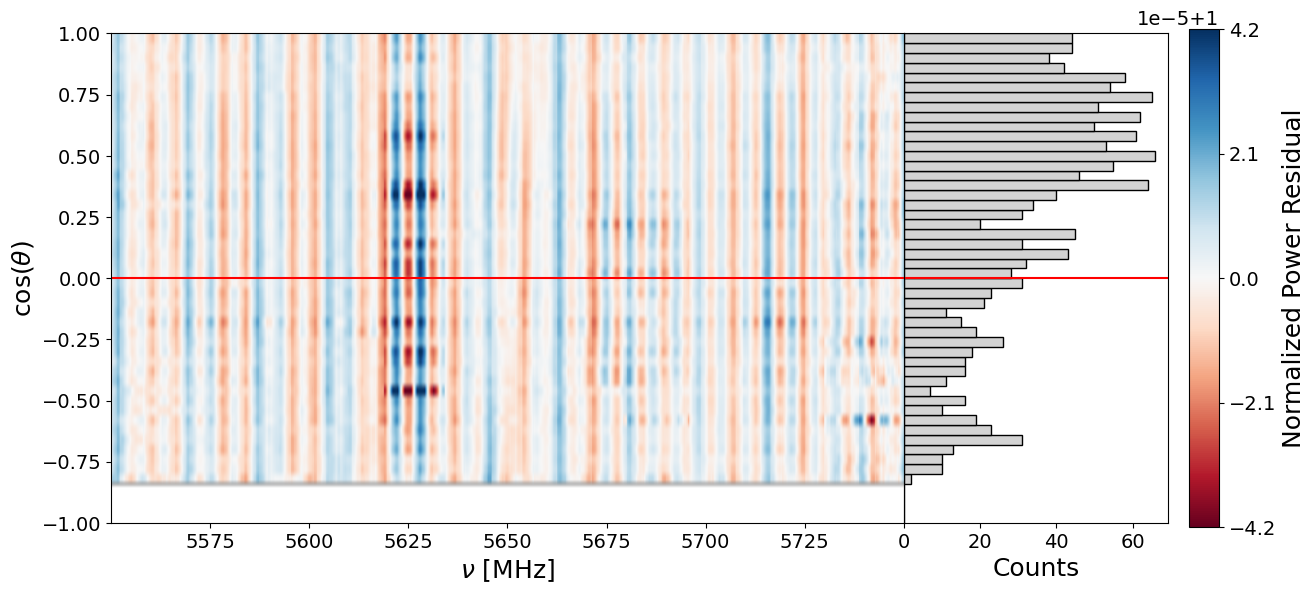

In [16]:
fig = plot_heatmap(
    'decay',
    1,
    inj_spectra,
    xs,
    info,
    n_bins=50,
    var='cos_theta',
    resid=1
)

### Injected - Aya's cones (all targets)

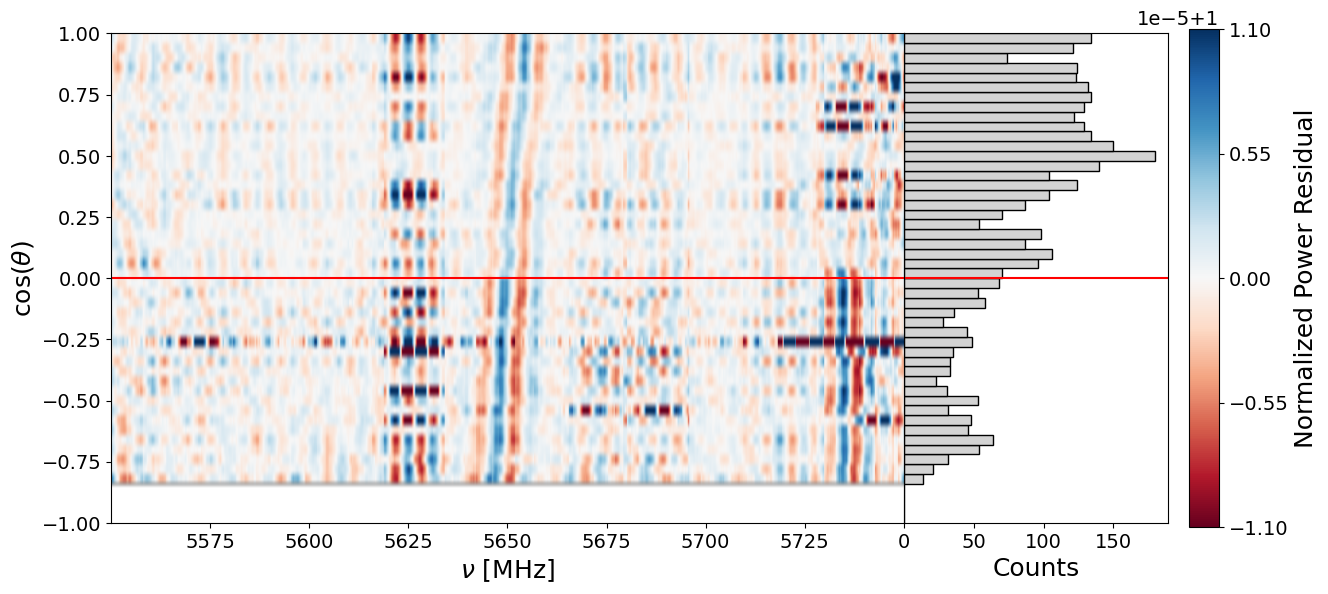

In [17]:
info_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/all_cband_info.csv'
info = pd.read_csv(info_dir)
bank_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/heatmap/052926_01/decay/1'
bank_1_info = info[info['source'].apply(lambda l: l+'.npy').isin(os.listdir(bank_dir))]
info = bank_1_info

inj_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/target_selection/norm_1e30_5650_tests/injected'
files = info['source'].apply(lambda l: l+'.npy').to_numpy()
xs = np.load(os.path.join(inj_dir, files[0]))[0]
inj_spectra = np.array([np.load(os.path.join(inj_dir, file))[1] for file in files])

fig = plot_heatmap(
    'decay',
    1,
    inj_spectra,
    xs,
    info,
    n_bins=50,
    var='cos_theta',
    resid=np.nanmean(inj_spectra, axis=0)
)

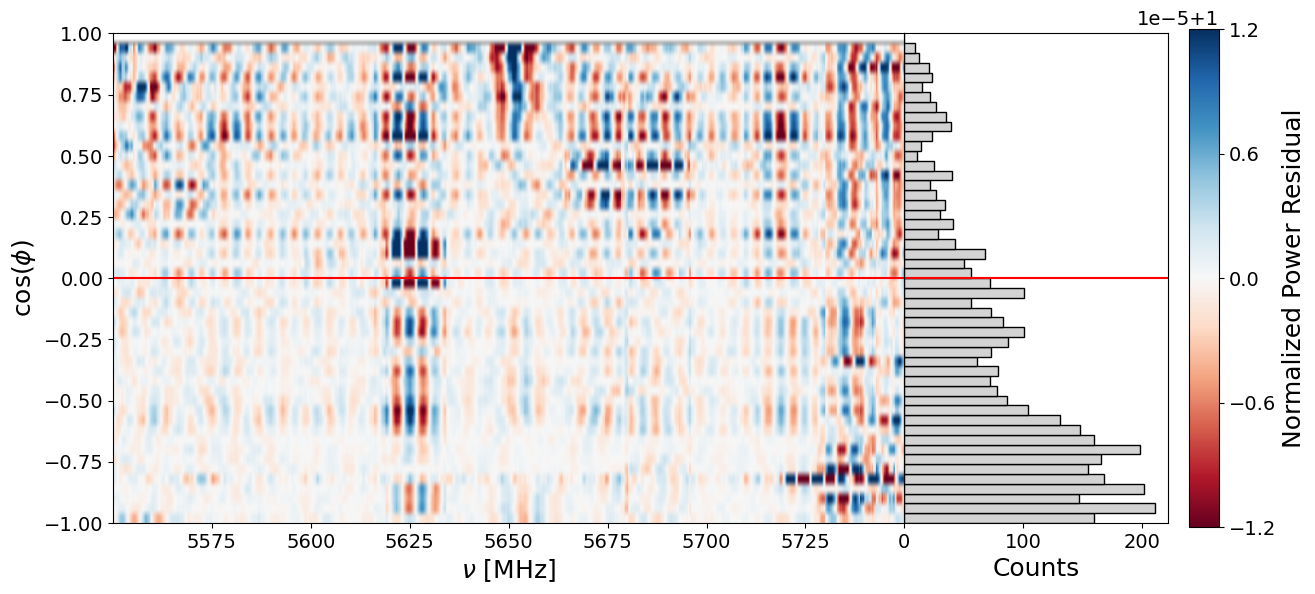

In [18]:
info_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/all_cband_info.csv'
info = pd.read_csv(info_dir)
bank_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/heatmap/052926_01/decay/1'
bank_1_info = info[info['source'].apply(lambda l: l+'.npy').isin(os.listdir(bank_dir))]
info = bank_1_info

inj_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/target_selection/norm_1e30_5650_tests/injected'
files = info['source'].apply(lambda l: l+'.npy').to_numpy()
xs = np.load(os.path.join(inj_dir, files[0]))[0]
inj_spectra = np.array([np.load(os.path.join(inj_dir, file))[1] for file in files])

fig = plot_heatmap(
    'decay',
    1,
    inj_spectra,
    xs,
    info,
    n_bins=50,
    var='cos_phi',
    resid=np.nanmean(inj_spectra, axis=0)
)

## Subtract instead of divide

In [ ]:
def plot_heatmap(case, bank, all_spectra, xs, info, n_bins=50, var='cos_phi', resid=None):
    nans = np.full(xs.shape, np.nan)

    info['time_mjd'] = info['time'].apply(lambda mjd: int(mjd.split('_')[0])) #[int(mjd.split('_')[0]) for mjd in info['time']]
    info['cos_theta'] = info['theta'].apply(lambda theta: math.cos(math.radians(theta))) #[math.cos(math.radians(theta)) for theta in info['theta']]
    info['cos_phi'] = info['phi'].apply(lambda phi: math.cos(math.radians(phi))) #[math.cos(math.radians(phi)) for phi in info['phi']]

    bounds = (min(info['time_mjd']), max(info['time_mjd'])) if var == 'time_mjd' else (-1, 1)
    bins = np.linspace(*bounds, n_bins+1)
    info['time_mjd_bin'] = pd.cut(info['time_mjd'], bins, labels=False)
    info['cos_theta_bin'] = pd.cut(info['cos_theta'], bins, labels=False)
    info['cos_phi_bin'] = pd.cut(info['cos_phi'], bins, labels=False)

    def create_map(bin_column):
        for i in range(n_bins):
            bin_mask = (info[bin_column] == i).to_numpy()
            spectra = all_spectra[bin_mask]
            if spectra.size:
                avg = np.mean(spectra, axis=0)
                yield avg
            else:
                yield nans
        
    heat_map = np.array(list(create_map(f'{var}_bin')))
    if resid is not None:
        heat_map = heat_map - resid

    fig = plt.figure(figsize=(12, 6), layout="tight")
    gs = fig.add_gridspec(1, 2, wspace=0, width_ratios=[3, 1])
    #plt.subplots_adjust(hspace=0.15)

    ax = fig.add_subplot(gs[0])
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(np.array(heat_map))
    if resid is not None:
        vmax = max(vmax, -vmin)
        ndigits = -int(math.floor(math.log10(vmax))) + 1
        vmax = round(vmax, ndigits)
        vmin = -vmax
    else:
        vmax = max(vmax, 2-vmin)
        ndigits = -int(math.floor(math.log10(vmax))) + 1
        vmax = round(vmax, ndigits)
        vmin = 2 - vmax
    norm = Normalize(vmin=vmin, vmax=vmax)
    extent = [np.min(xs[mask]), np.max(xs[mask]), *bounds]

    #im0 = axs[0].imshow(theta_map, extent=extent, origin='lower', norm=norm, aspect='auto')
    im1 = ax.imshow(heat_map, extent=extent, cmap='RdBu' if resid is not None else 'viridis', origin='lower', norm=norm, aspect='auto')
    
    #axs[0].set_ylabel(r'$\mathrm{cos}({\theta})$', fontsize=18)
    if var == 'cos_phi':
        label = r'$\mathrm{cos}({\phi})$'
    elif var == 'cos_theta':
        label = r'$\mathrm{cos}({\theta})$'
    else:
        label = 'Modified JD'

    ax.set_ylabel(label, fontsize=18)
    ax.set_xlabel(r'$\nu$ [MHz]', fontsize=18)
    # for i in bins:
    #     ax.axhline(i, c='r')

    hist_ax = fig.add_subplot(gs[1])
    hist_ax.hist(info[var], bins=bins, facecolor='lightgray', edgecolor='k', orientation='horizontal')
    hist_ax.set_xlabel('Counts', fontsize=18)
    hist_ax.set_yticks([])
    hist_ax.set_ylim(*bounds)

    if var != 'time_mjd':
        ax.axhline(0, c='r') # Inward/outward division
        hist_ax.axhline(0, c='r') # Inward/outward division
        ax.set_yticks(np.linspace(-1, 1, 9))

    #fig.suptitle(f'Bank {bank} {case}', fontsize=20)
    ax.set_aspect('auto')

    #tick_locs = ax[0].get_xticks
    #axs[0].set_xticklabels([])
    #axs[1].set_xticklabels([round(loc * freqs + min(xs)) for loc in tick_locs])
    cax = fig.add_axes([1, 0.13, 0.025, 0.83])
    cbar = fig.colorbar(im1, cax=cax, ax=ax, orientation='vertical', ticks=np.linspace(vmin, vmax, 5))
    cbar.set_label('Normalized Power Residual' if resid is not None else 'Normalized Power', fontsize=18)
    
    return fig

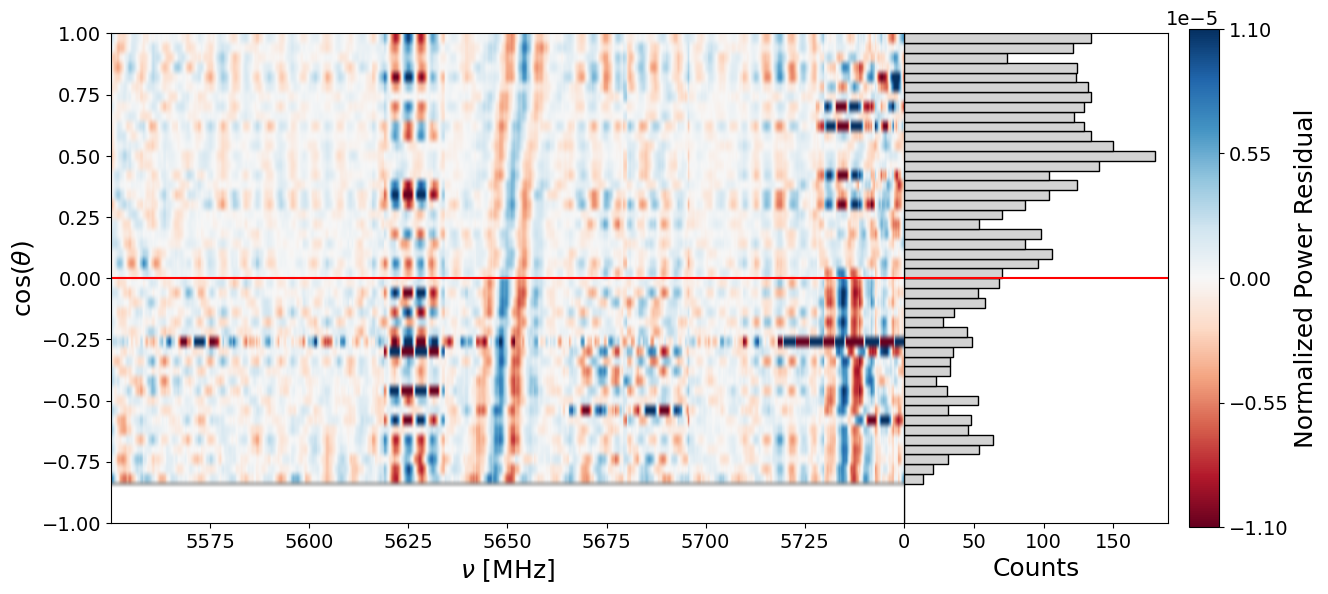

In [26]:
info_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/all_cband_info.csv'
info = pd.read_csv(info_dir)
bank_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/heatmap/052926_01/decay/1'
bank_1_info = info[info['source'].apply(lambda l: l+'.npy').isin(os.listdir(bank_dir))]
info = bank_1_info

inj_dir = '/home/dataadmin/GBTData/SharedDataDirectory/cband_052726/target_selection/norm_1e30_5650_tests/injected'
files = info['source'].apply(lambda l: l+'.npy').to_numpy()
xs = np.load(os.path.join(inj_dir, files[0]))[0]
inj_spectra = np.array([np.load(os.path.join(inj_dir, file))[1] for file in files])

fig = plot_heatmap(
    'decay',
    1,
    inj_spectra,
    xs,
    info,
    n_bins=50,
    var='cos_theta',
    resid=np.nanmean(inj_spectra, axis=0)
)